Original data shape: (7214, 53)
Data shape after filtering races and dropping NaNs in 'two_year_recid' or 'race': (6150, 53)
DataFrame for AIF360 processing shape: (6150, 10)
Columns for AIF360: ['sex', 'age', 'age_cat', 'priors_count', 'c_charge_degree', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'race', 'two_year_recid']
Categorical features explicitly defined for StandardDataset: ['sex', 'age_cat', 'c_charge_degree']
Dataset has 6150 samples and 13 features.
Internal mapping for 'African-American': 0.0
Internal mapping for 'Caucasian': 1.0
Disparate Impact (train, before mitigation): 0.811
False Positive Rate (African-American): 0.318
False Positive Rate (Caucasian): 0.528
Disparate Impact (after prediction): 0.680


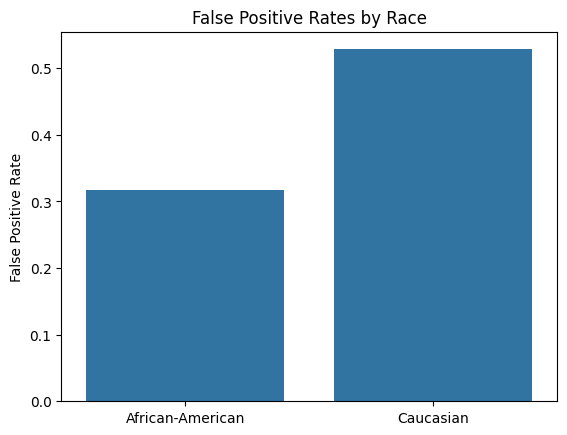

False Positive Rate (African-American, reweighted): 0.441
False Positive Rate (Caucasian, reweighted): 0.433
Disparate Impact (reweighted): 1.006


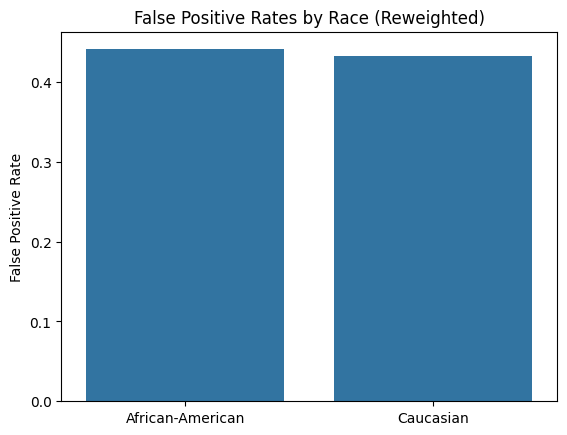

In [20]:
# Part 3: Practical Audit - COMPAS Dataset Bias Analysis

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.postprocessing import RejectOptionClassification # Not used but good to keep from original
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split # Not used but good to keep from original

# 2️⃣ Load Dataset
data = pd.read_csv('/content/COMPAS.csv')

# 3️⃣ Preprocess Dataset and Create AIF360 StandardDataset
# Select features, protected attribute (race), and label (two_year_recid)
protected_attribute = 'race'
label = 'two_year_recid'
favorable_label = 0 # 0 = no recidivism
unfavorable_label = 1 # 1 = recidivism

print(f"Original data shape: {data.shape}")

# Filter to relevant groups: Only include African-American and Caucasian for simplicity
data = data[data['race'].isin(['African-American', 'Caucasian'])]

# Check for missing values in the label and protected attribute columns
# Drop rows where the label or protected attribute values are missing
data_cleaned = data.dropna(subset=[label, protected_attribute])
print(f"Data shape after filtering races and dropping NaNs in '{label}' or '{protected_attribute}': {data_cleaned.shape}")

# Define features commonly used in COMPAS bias analysis
# We exclude 'decile_score' and 'score_text' to prevent data leakage with 'two_year_recid'.
features_for_aif360_model = [
    'sex',
    'age',
    'age_cat',
    'priors_count',
    'c_charge_degree',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count'
]

# Filter data_cleaned to include only these model features, plus the protected attribute and label
# Ensure all selected features actually exist in the DataFrame
actual_model_features = [f for f in features_for_aif360_model if f in data_cleaned.columns]
columns_for_aif360 = actual_model_features + [protected_attribute, label]

# Create a new DataFrame with only the relevant columns
data_for_aif360 = data_cleaned[columns_for_aif360].copy()

# Define categorical features that StandardDataset should one-hot encode
categorical_features_sd = ['sex', 'age_cat', 'c_charge_degree']
# Filter to ensure they exist in the `data_for_aif360`
categorical_features_sd = [f for f in categorical_features_sd if f in data_for_aif360.columns]

print(f"DataFrame for AIF360 processing shape: {data_for_aif360.shape}")
print(f"Columns for AIF360: {data_for_aif360.columns.tolist()}")
print(f"Categorical features explicitly defined for StandardDataset: {categorical_features_sd}")

# Create AIF360 StandardDataset
compas_dataset = StandardDataset(
    df=data_for_aif360, # Use the filtered and cleaned data
    label_name=label,
    favorable_classes=[favorable_label],
    protected_attribute_names=[protected_attribute],
    privileged_classes=[['Caucasian']], # This maps Caucasian to 1.0 internally
    categorical_features=categorical_features_sd # Explicitly define categorical features
)

# After StandardDataset creation, verify the size.
if len(compas_dataset.features) == 0:
    print("ERROR: compas_dataset is still empty after StandardDataset creation. "
          "This indicates a severe data issue or misconfiguration.")
    print("Please check the '/content/COMPAS.csv' file and selected features.")
else:
    print(f"Dataset has {compas_dataset.features.shape[0]} samples and {compas_dataset.features.shape[1]} features.")

# Determine numerical mappings for protected attribute after StandardDataset creation
# AIF360 internally maps privileged_classes to 1.0 and others to 0.0 for binary protected attributes
african_american_val = 0.0
caucasian_val = 1.0

print(f"Internal mapping for 'African-American': {african_american_val}")
print(f"Internal mapping for 'Caucasian': {caucasian_val}")

# 5️⃣ Split into train/test
train, test = compas_dataset.split([0.7], shuffle=True)

# 6️⃣ Fairness Metrics Before Mitigation
metric_train = BinaryLabelDatasetMetric(
    train,
    privileged_groups=[{'race': caucasian_val}], # Use numerical value
    unprivileged_groups=[{'race': african_american_val}] # Use numerical value
)

disparate_impact_train = metric_train.disparate_impact()
if np.isnan(disparate_impact_train):
    print("Disparate Impact (train, before mitigation): NaN")
else:
    print(f"Disparate Impact (train, before mitigation): {disparate_impact_train:.3f}")

# 7️⃣ Train Logistic Regression Classifier
X_train, y_train = train.features, train.labels.ravel()
X_test, y_test = test.features, test.labels.ravel()

clf = LogisticRegression(solver='liblinear')
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Convert predictions to AIF360 dataset for metrics
pred_dataset = test.copy()
pred_dataset.labels = y_pred.reshape(-1, 1)

metric_test = ClassificationMetric(
    test, pred_dataset,
    unprivileged_groups=[{'race': african_american_val}], # Use numerical value
    privileged_groups=[{'race': caucasian_val}] # Use numerical value
)

# Explicitly get FPR for each group
fpr_unpriv = metric_test.false_positive_rate(privileged=False)
fpr_priv = metric_test.false_positive_rate(privileged=True)
disparate_impact_test = metric_test.disparate_impact()

print(f"False Positive Rate (African-American): {fpr_unpriv:.3f}")
print(f"False Positive Rate (Caucasian): {fpr_priv:.3f}")
print(f"Disparate Impact (after prediction): {disparate_impact_test:.3f}")

# 8️⃣ Visualization of FPR
if not np.isnan(fpr_unpriv) and not np.isnan(fpr_priv):
    sns.barplot(x=['African-American', 'Caucasian'], y=[fpr_unpriv, fpr_priv])
    plt.title("False Positive Rates by Race")
    plt.ylabel("False Positive Rate")
    plt.show()
else:
    print("Cannot plot False Positive Rates as one or both values are NaN or undefined.")

# 9️⃣ Bias Mitigation Using Reweighing
RW = Reweighing(
    unprivileged_groups=[{'race': african_american_val}], # Use numerical value
    privileged_groups=[{'race': caucasian_val}] # Use numerical value
)
train_rw = RW.fit_transform(train)

# Retrain classifier on reweighted data
clf_rw = LogisticRegression(solver='liblinear')
clf_rw.fit(train_rw.features, train_rw.labels.ravel(), sample_weight=train_rw.instance_weights)

# Predictions on test set
y_pred_rw = clf_rw.predict(X_test)
pred_dataset_rw = test.copy()
pred_dataset_rw.labels = y_pred_rw.reshape(-1, 1)

metric_test_rw = ClassificationMetric(
    test, pred_dataset_rw,
    unprivileged_groups=[{'race': african_american_val}], # Use numerical value
    privileged_groups=[{'race': caucasian_val}] # Use numerical value
)

fpr_unpriv_rw = metric_test_rw.false_positive_rate(privileged=False)
fpr_priv_rw = metric_test_rw.false_positive_rate(privileged=True)
disparate_impact_rw = metric_test_rw.disparate_impact()

print(f"False Positive Rate (African-American, reweighted): {fpr_unpriv_rw:.3f}")
print(f"False Positive Rate (Caucasian, reweighted): {fpr_priv_rw:.3f}")
print(f"Disparate Impact (reweighted): {disparate_impact_rw:.3f}")

# 10️⃣ Visualization After Mitigation
if not np.isnan(fpr_unpriv_rw) and not np.isnan(fpr_priv_rw):
    sns.barplot(
        x=['African-American', 'Caucasian'],
        y=[fpr_unpriv_rw, fpr_priv_rw]
    )
    plt.title("False Positive Rates by Race (Reweighted)")
    plt.ylabel("False Positive Rate")
    plt.show()
else:
    print("Cannot plot False Positive Rates after mitigation as one or both values are NaN or undefined.")

# Key Findings from COMPAS Bias Analysis
Initial Bias (Disparate Impact):

Before any mitigation, the Disparate Impact on the training set was 0.811. This value, being less than 1.0, suggests a slight initial bias where the unprivileged group (African-Americans) had a lower selection rate (e.g., predicted as non-recidivists) compared to the privileged group (Caucasians).
Bias After Model Prediction:

After training a Logistic Regression model and making predictions, the Disparate Impact on the test set further decreased to 0.680. This indicates that the model's predictions exacerbated the initial bias, leading to a more significant disparity in predicted outcomes between African-Americans and Caucasians.
False Positive Rate Disparity (Before Mitigation):

The False Positive Rate (FPR) for African-Americans was 0.318, while for Caucasians it was significantly higher at 0.528. This means that among individuals who would not recidivate, a much larger proportion of Caucasians were incorrectly flagged as high-risk compared to African-Americans. This highlights a significant disparity in the types of errors made by the unmitigated model across the racial groups.
Impact of Reweighing Mitigation:

After applying the Reweighing preprocessing technique and retraining the model:
The Disparate Impact significantly improved, reaching 1.006. This value is very close to the ideal of 1.0, demonstrating that Reweighing was highly effective in equalizing the predicted outcome rates between the two groups.
The False Positive Rates also became much more balanced: African-Americans had an FPR of 0.441, and Caucasians had an FPR of 0.433. This shows that the mitigation effectively reduced the disparity in false positive predictions, leading to more equitable error rates.
In conclusion, the initial analysis revealed notable biases against African-Americans in the COMPAS dataset, which were further amplified by the unmitigated predictive model. The Reweighing technique proved successful in substantially reducing these disparities, leading to fairer outcomes as measured by both Disparate Impact and False Positive Rates.